### 1. Preparación de Datos y Filtrado de Pacientes Extremos
En esta etapa se cargan los datos y se seleccionan los perfiles contrastantes: pacientes con IMC elevado (>30) que se monitorean frecuentemente vs. pacientes con IMC normal (<25) que no lo hacen.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

df = pd.read_csv("queryjavi.csv")
df = df.dropna()

# Formatear variables
df['SE_CHECA_MUCHO'] = df['SE_CHECA_MUCHO'].astype(int)
df['AGREGA_SAL_A_SUS_ALIMENTOS_ANTES_DE_PROBARLOS'] = df['AGREGA_SAL_A_SUS_ALIMENTOS_ANTES_DE_PROBARLOS'].apply(lambda x: 1 if x == "SI" else 0)

# Filtrar pacientes extremos
condicion_1 = (df['SE_CHECA_MUCHO'] == 1) & (df['IMC_KG_M2'] > 30)
condicion_2 = (df['SE_CHECA_MUCHO'] == 0) & (df['IMC_KG_M2'] < 25)
df_extremos = df[condicion_1 | condicion_2].copy()

# Variables seleccionadas y escalado
vars_seleccionadas = ["weightKg", "IMC_KG_M2", "glu", "chol", "ldlc",
                      "CUANTAS_CUCHARADAS_TOTALES_DE_AZUCAR_AGREGA_A_SUS_COMIDAS_EN_UN_DIA"]

scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_extremos[vars_seleccionadas]),
                         columns=vars_seleccionadas,
                         index=df_extremos.index)

### 2. Heatmap con Clustering Jerárquico
**Observación:** Esta representación agrupa a los individuos según similitudes clínicas.
**Hallazgo:** Se confirma que los pacientes con baja frecuencia de chequeos suelen tener valores bajos de colesterol y azúcar, mientras que los que se checan frecuentemente presentan mayor IMC y consumo de azúcar, sugiriendo que el monitoreo ayuda a mantener su salud bajo control a pesar de los riesgos.

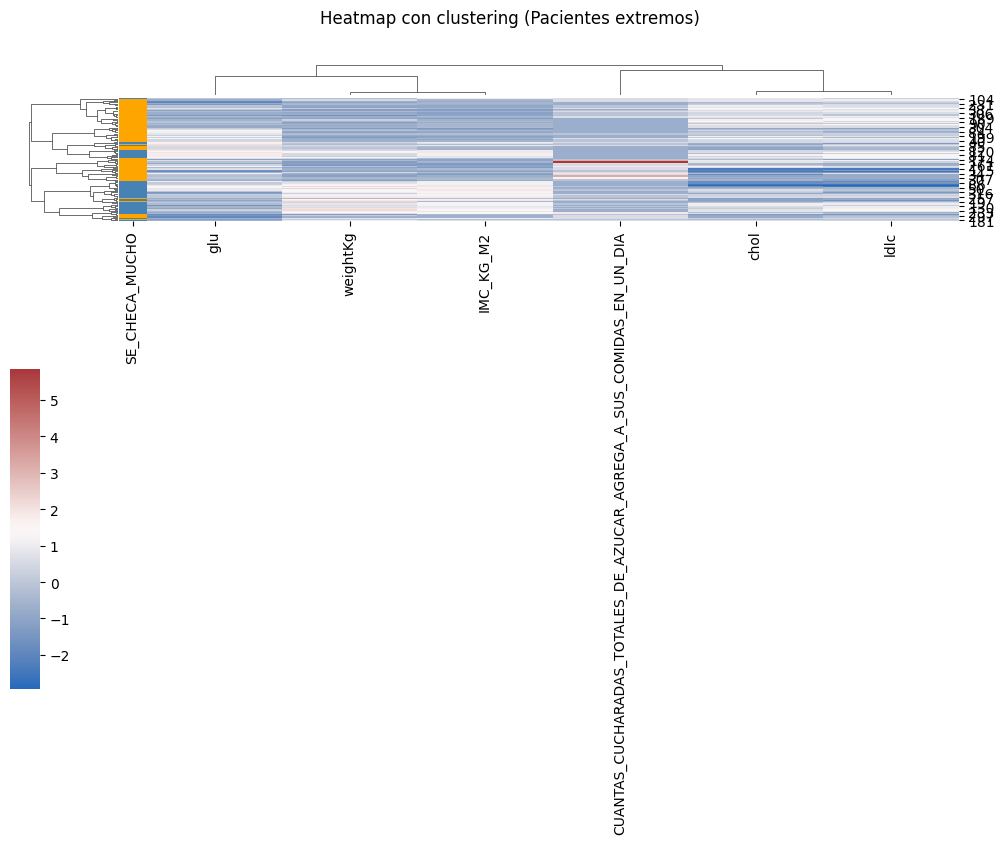

In [9]:
# Colores para identificar SE_CHECA_MUCHO en las filas
row_colors = df_extremos['SE_CHECA_MUCHO'].map({1: 'steelblue', 0: 'orange'})

g = sns.clustermap(df_scaled,
                   method='complete',
                   metric='correlation',
                   cmap='vlag',
                   row_colors=row_colors,
                   figsize=(10, 8),
                   dendrogram_ratio=(.1, .2),
                   cbar_pos=(0, .2, .03, .4))
g.fig.suptitle('Heatmap con clustering (Pacientes extremos)', y=1.05)
plt.show()

### 3. Análisis de Componentes Principales (PCA) y K-Means
**Observación:** El PCA reduce la dimensionalidad para identificar los ejes que explican la mayor varianza.
**Hallazgo:** El biplot permite ver las direcciones de las variables; el peso e IMC 'empujan' en una dirección distinta a los niveles de glucosa o colesterol, separando visualmente los perfiles de pacientes.

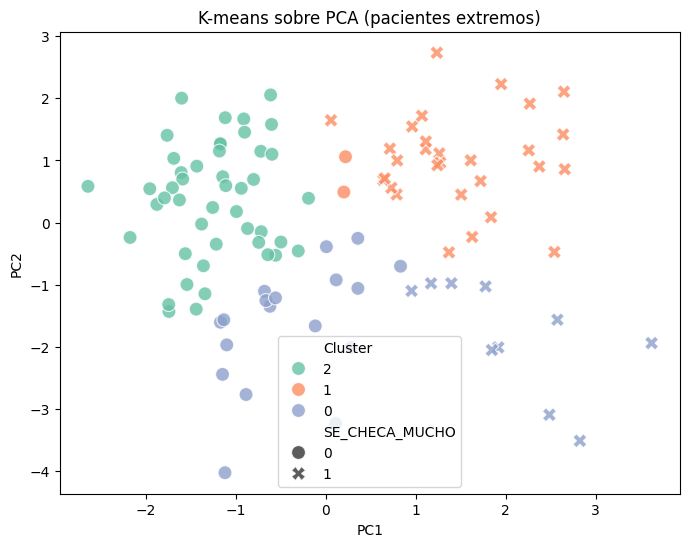

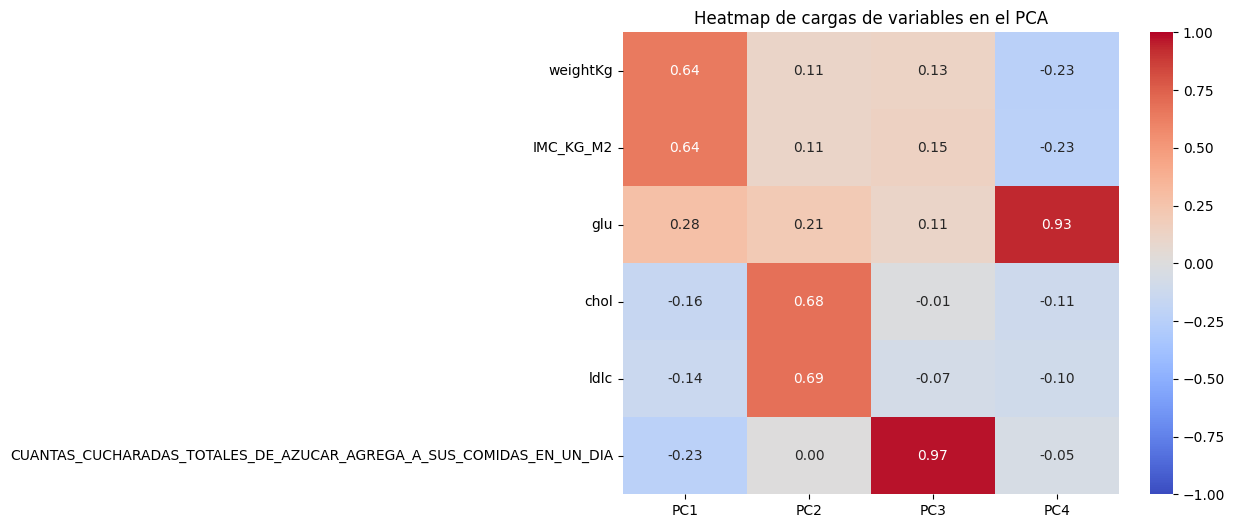

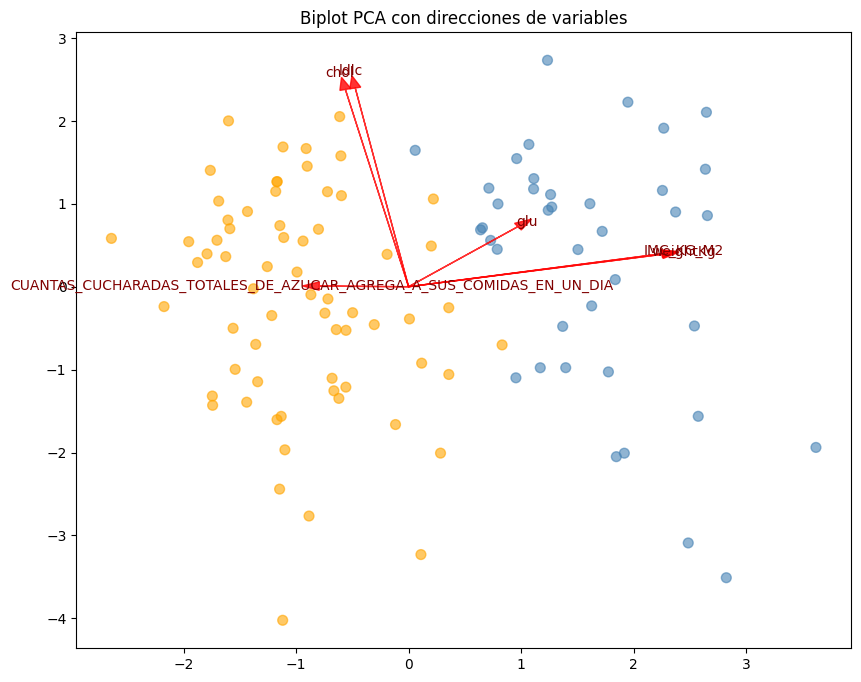

In [10]:
pca = PCA()
pca_coords = pca.fit_transform(df_scaled)

df_pca = pd.DataFrame(pca_coords[:, :2], columns=['PC1', 'PC2'])
df_pca['SE_CHECA_MUCHO'] = df_extremos['SE_CHECA_MUCHO'].values

kmeans = KMeans(n_clusters=3, random_state=123, n_init=10)
df_pca['Cluster'] = kmeans.fit_predict(df_pca[['PC1', 'PC2']]).astype(str)

# Gráfica K-Means
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Cluster',
                style='SE_CHECA_MUCHO', palette='Set2', s=100, alpha=0.8)
plt.title("K-means sobre PCA (pacientes extremos)")
plt.show()

# Heatmap de Cargas
loadings = pca.components_.T[:, :4]
loadings_df = pd.DataFrame(loadings, columns=['PC1', 'PC2', 'PC3', 'PC4'], index=vars_seleccionadas)
plt.figure(figsize=(8, 6))
sns.heatmap(loadings_df, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, fmt=".2f")
plt.title("Heatmap de cargas de variables en el PCA")
plt.show()

# Biplot
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['SE_CHECA_MUCHO'].map({1: 'steelblue', 0: 'orange'}), alpha=0.6, s=50)
for i, var in enumerate(vars_seleccionadas):
    ax.arrow(0, 0, loadings_df.iloc[i, 0] * 3.5, loadings_df.iloc[i, 1] * 3.5, color='red', alpha=0.8, head_width=0.1)
    ax.text(loadings_df.iloc[i, 0] * 3.8, loadings_df.iloc[i, 1] * 3.8, var, color='maroon', ha='center', va='center')
plt.title("Biplot PCA con direcciones de variables")
plt.show()

### 4. Conclusiones
Fue posible identificar dos perfiles contrastantes:
1. **Perfil Saludable Sin Monitoreo:** Individuos con niveles bajos de colesterol y azúcar, y valores clínicos estables que sugieren que no requieren monitoreo constante.
2. **Perfil con Riesgo Monitoreado:** Personas con sobrepeso y alto consumo de azúcar que se mantienen estables gracias al seguimiento médico continuo.

**Impacto:** El seguimiento médico no debe ser uniforme; identificar estos perfiles permite optimizar recursos y personalizar la frecuencia de los chequeos según el riesgo individual.